In [17]:
# preprocessing -->
#  avg of all attributes for each day
# Handle missing values


In [18]:
# from google.colab import drive
# drive.mount('/content/drive')

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("Jena_Dataset.csv", encoding='ISO-8859-1')

# Preprocess the dataset
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.dropna(inplace=True)  # Handle missing values

# Feature selection
X = df.drop(['T (degC)'], axis=1)  # Features
y = df['T (degC)']               # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = rf_model.predict(X_test)

print(f"Random Forest Model Performance:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test, y_pred):.2f}")

Random Forest Model Performance:
Mean Squared Error (MSE): 0.04
R-squared (R2 Score): 1.00


How Random Forest Works for This Dataset
Multiple Decision Trees:

Random Forest builds many decision trees (each trained on random subsets of data and features).
For example, one tree may focus more on p (mbar) and Tdew (degC), while another may emphasize rh (%) and CO2 (ppm).
Random Feature Selection:

Each tree only considers a random subset of features at each split. This adds variety and prevents trees from relying too heavily on a few dominant features.
Ensemble Prediction:

In regression tasks (like predicting T (degC)), Random Forest takes the average of all tree predictions.
This averaging reduces variance and improves stability.
Strengths in Weather Data:

Since weather data can be noisy and complex, Random Forest’s ability to handle non-linear relationships and feature interactions makes it ideal for this dataset.
It effectively manages missing data and irrelevant features (even if they exist).
Key Parameters
n_estimators: Number of trees in the forest (higher values improve stability but increase computation).
max_depth: Limits tree depth to control overfitting.
random_state: Ensures reproducibility.

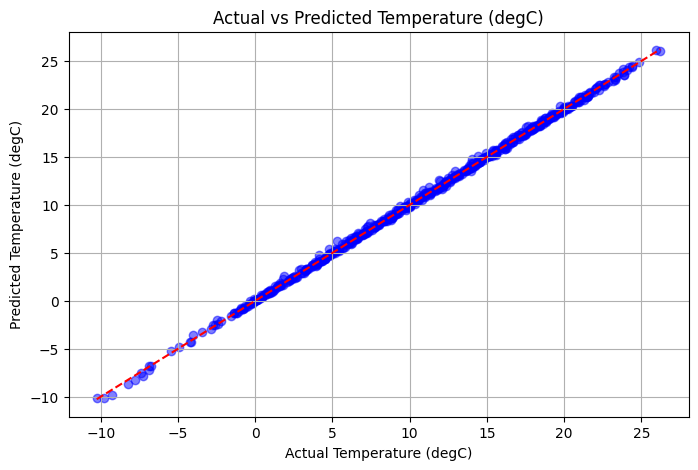

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Temperature (degC)')
plt.xlabel('Actual Temperature (degC)')
plt.ylabel('Predicted Temperature (degC)')
plt.grid(True)
plt.show()


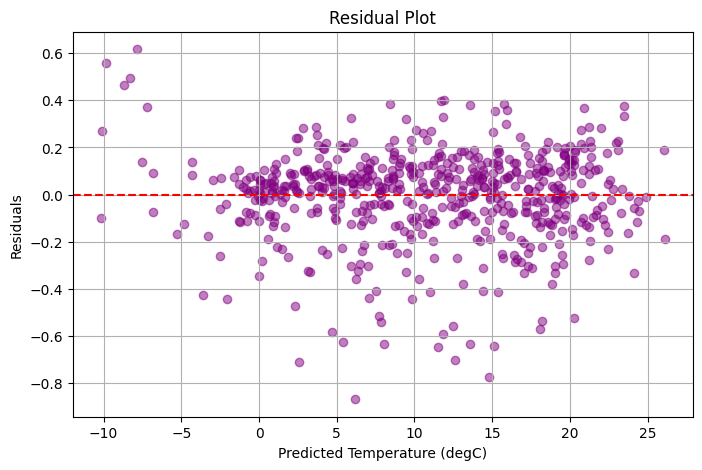

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, y_test - y_pred, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Temperature (degC)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


How Gradient Boosting Works for This Dataset
Sequential Learning:
Gradient Boosting builds decision trees one at a time, with each new tree learning from the errors (residuals) of the previous one. For example, one tree may focus more on VPact (mbar) and Tdew (degC), while another may emphasize rho (g/m3) and PAR (µmol/m2/s).

Error Correction:
Each tree is trained to predict the residual errors (the difference between actual and predicted values). The model then updates its predictions by adding these corrections. This process repeats for multiple trees, gradually improving accuracy.

Weighted Contribution:
Gradient Boosting assigns weights to each tree's predictions, giving more influence to stronger models and less to weaker ones.

Strengths in Weather Data:
Since weather data often has complex patterns and non-linear relationships, Gradient Boosting excels at capturing these. It can also adapt well to slight changes in data, making it robust for forecasting.

Key Parameters:

n_estimators: Number of boosting stages (more stages improve performance but may overfit).
learning_rate: Controls the contribution of each tree — lower values improve stability.
max_depth: Limits tree depth to control overfitting.
random_state: Ensures reproducibility.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("Jena_Dataset.csv", encoding='ISO-8859-1')

# Preprocess the dataset
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.dropna(inplace=True)  # Handle missing values

# Feature selection
X = df.drop(['T (degC)'], axis=1)  # Features
y = df['T (degC)']               # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting Model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
# gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.5, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = gb_model.predict(X_test)

print(f"Gradient Boosting Model Performance:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test, y_pred):.2f}")

Gradient Boosting Model Performance:
Mean Squared Error (MSE): 0.03
R-squared (R2 Score): 1.00


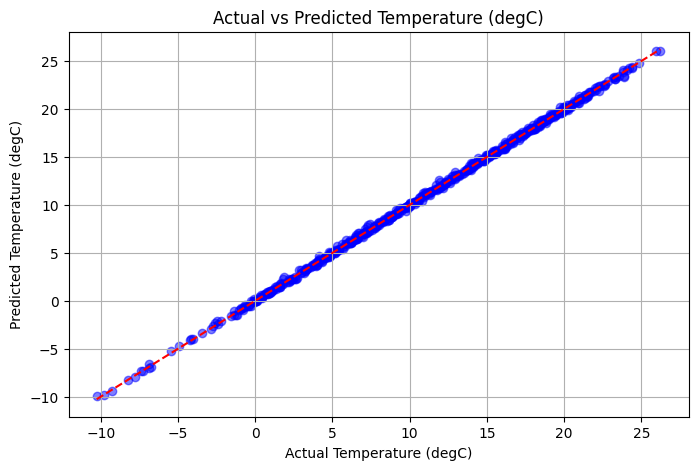

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Temperature (degC)')
plt.xlabel('Actual Temperature (degC)')
plt.ylabel('Predicted Temperature (degC)')
plt.grid(True)
plt.show()


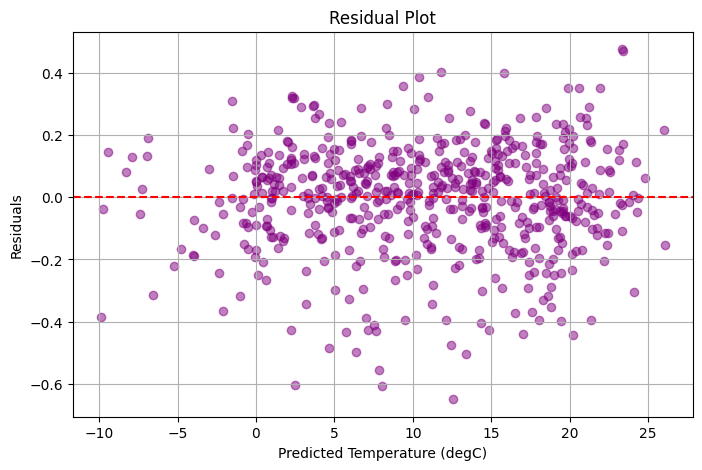

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, y_test - y_pred, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Temperature (degC)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("Jena_Dataset.csv", encoding='ISO-8859-1')

# Preprocess the dataset
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.dropna(inplace=True)  # Handle missing values

# Feature selection
X = df.drop(['T (degC)'], axis=1)  # Features
y = df['T (degC)']               # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM Model
svm_model = SVR(kernel='rbf', C=1, gamma=0.01)
svm_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = svm_model.predict(X_test)

print(f"SVM Model Performance:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test, y_pred):.2f}")



SVM Model Performance:
Mean Squared Error (MSE): 56.70
R-squared (R2 Score): 0.00


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("Jena_Dataset.csv", encoding='ISO-8859-1')

# Preprocess the dataset
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.dropna(inplace=True)  # Handle missing values

# Feature selection
X = df.drop(['T (degC)'], axis=1)  # Features
y = df['T (degC)']               # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Model
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = dt_model.predict(X_test)

print(f"Decision Tree Model Performance:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test, y_pred):.2f}")


Decision Tree Model Performance:
Mean Squared Error (MSE): 0.07
R-squared (R2 Score): 1.00


How Decision Tree Works for This Dataset
Single Decision Tree:

The Decision Tree builds a single tree that learns decision rules based on the dataset's features.
For example, the first split may be on Tpot (K) if it's the most important feature, dividing data into two groups: one for Tpot (K) < 290 and one for Tpot (K) ≥ 290.
Feature-Based Splitting:

At each split, the tree selects the feature that best reduces prediction error (using metrics like MSE).
For instance, one branch may focus on Tdew (degC) while another may prioritize PAR (µmol/m2/s).
Leaf Nodes (Final Predictions):

The process continues until the tree reaches its stopping criteria (e.g., max_depth or minimal error gain).
Each leaf node holds the average temperature value for the data points in that group.
Strengths in Weather Data:

Decision Trees excel in identifying non-linear patterns, making them useful for weather prediction.
They automatically adapt to important features, even in noisy datasets.
Key Parameters:

max_depth: Limits the depth of the tree to avoid overfitting.
min_samples_split: Sets the minimum number of samples required to split a node.
random_state: Ensures consistent results for reproducibility.

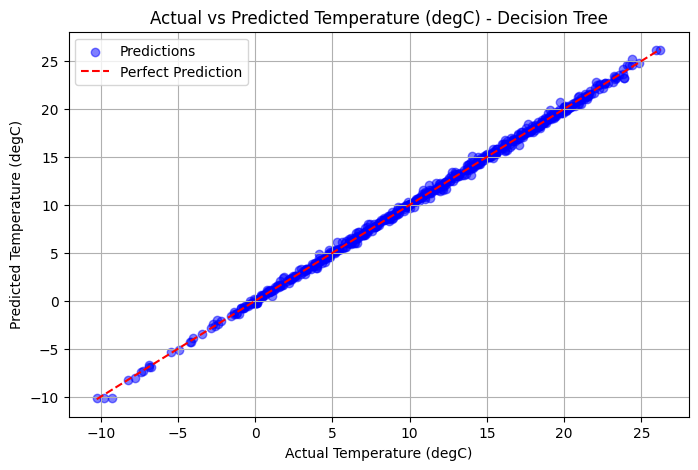

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs Predicted Temperature (degC) - Decision Tree')
plt.xlabel('Actual Temperature (degC)')
plt.ylabel('Predicted Temperature (degC)')
plt.legend()
plt.grid(True)
plt.show()


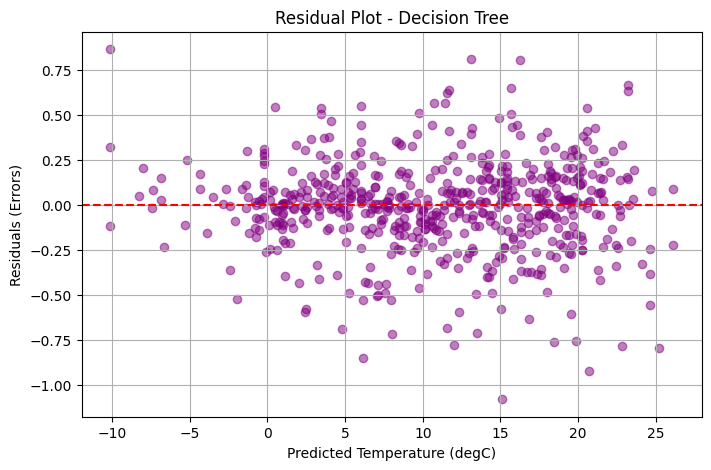

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, y_test - y_pred, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residual Plot - Decision Tree')
plt.xlabel('Predicted Temperature (degC)')
plt.ylabel('Residuals (Errors)')
plt.grid(True)
plt.show()


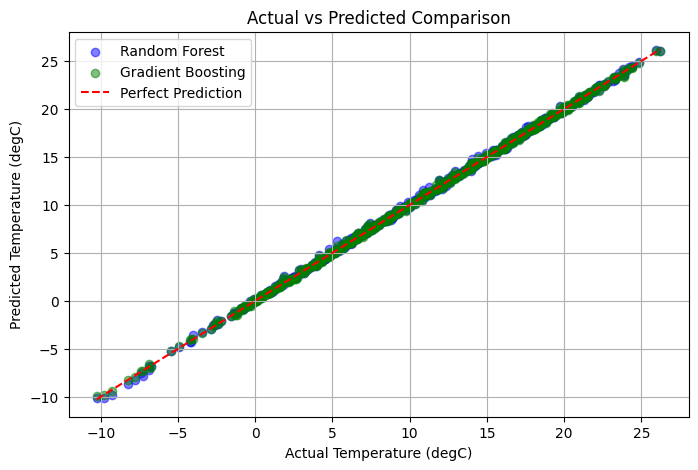

In [29]:
# RF vs GB

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Random Forest Predictions
plt.scatter(y_test, rf_model.predict(X_test), color='blue', alpha=0.5, label='Random Forest')

# Gradient Boosting Predictions
plt.scatter(y_test, gb_model.predict(X_test), color='green', alpha=0.5, label='Gradient Boosting')

# Perfect Prediction Line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs Predicted Comparison')
plt.xlabel('Actual Temperature (degC)')
plt.ylabel('Predicted Temperature (degC)')
plt.legend()
plt.grid(True)
plt.show()


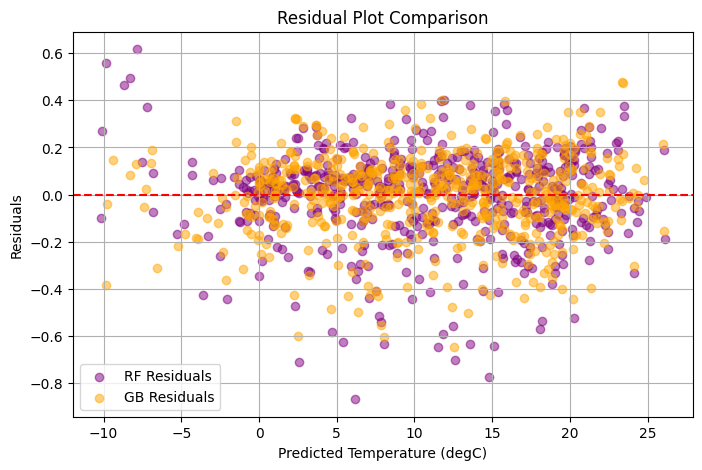

In [30]:
plt.figure(figsize=(8, 5))

# Random Forest Residuals
plt.scatter(rf_model.predict(X_test), y_test - rf_model.predict(X_test), color='purple', alpha=0.5, label='RF Residuals')

# Gradient Boosting Residuals
plt.scatter(gb_model.predict(X_test), y_test - gb_model.predict(X_test), color='orange', alpha=0.5, label='GB Residuals')

# Zero Error Line
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residual Plot Comparison')
plt.xlabel('Predicted Temperature (degC)')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.show()


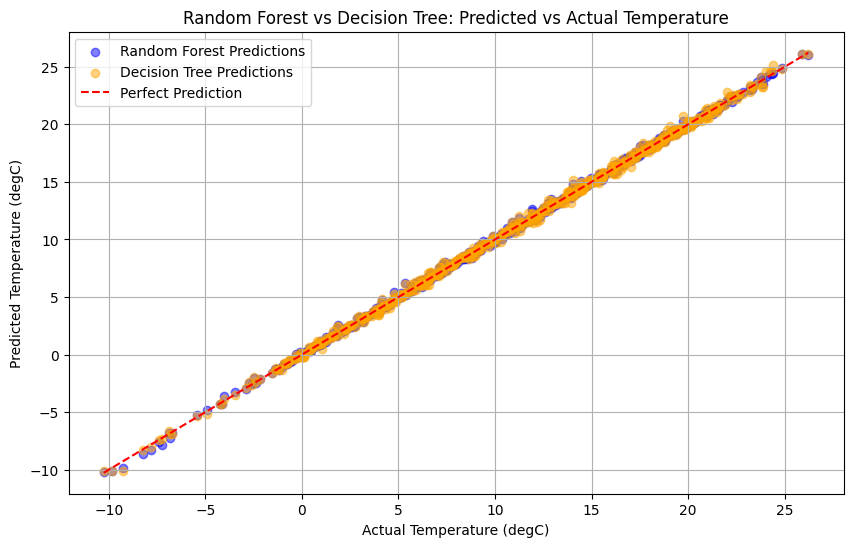

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions from both models
y_pred_rf = rf_model.predict(X_test)  # Random Forest Predictions
y_pred_dt = dt_model.predict(X_test)  # Decision Tree Predictions

# Plotting
plt.figure(figsize=(10, 6))

# Actual vs Random Forest
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.5, label='Random Forest Predictions')

# Actual vs Decision Tree
plt.scatter(y_test, y_pred_dt, color='orange', alpha=0.5, label='Decision Tree Predictions')

# Perfect Prediction Line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Random Forest vs Decision Tree: Predicted vs Actual Temperature')
plt.xlabel('Actual Temperature (degC)')
plt.ylabel('Predicted Temperature (degC)')
plt.legend()
plt.grid(True)
plt.show()


Random Forest - MSE: 0.0296 | R²: 0.9994
Gradient Boosting - MSE: 0.0272 | R²: 0.9995
XGBoost - MSE: 0.0406 | R²: 0.9992
Ensemble - MSE: 0.0230 | R²: 0.9996
Predicted temperature on 2025-08-29: 18.64°C


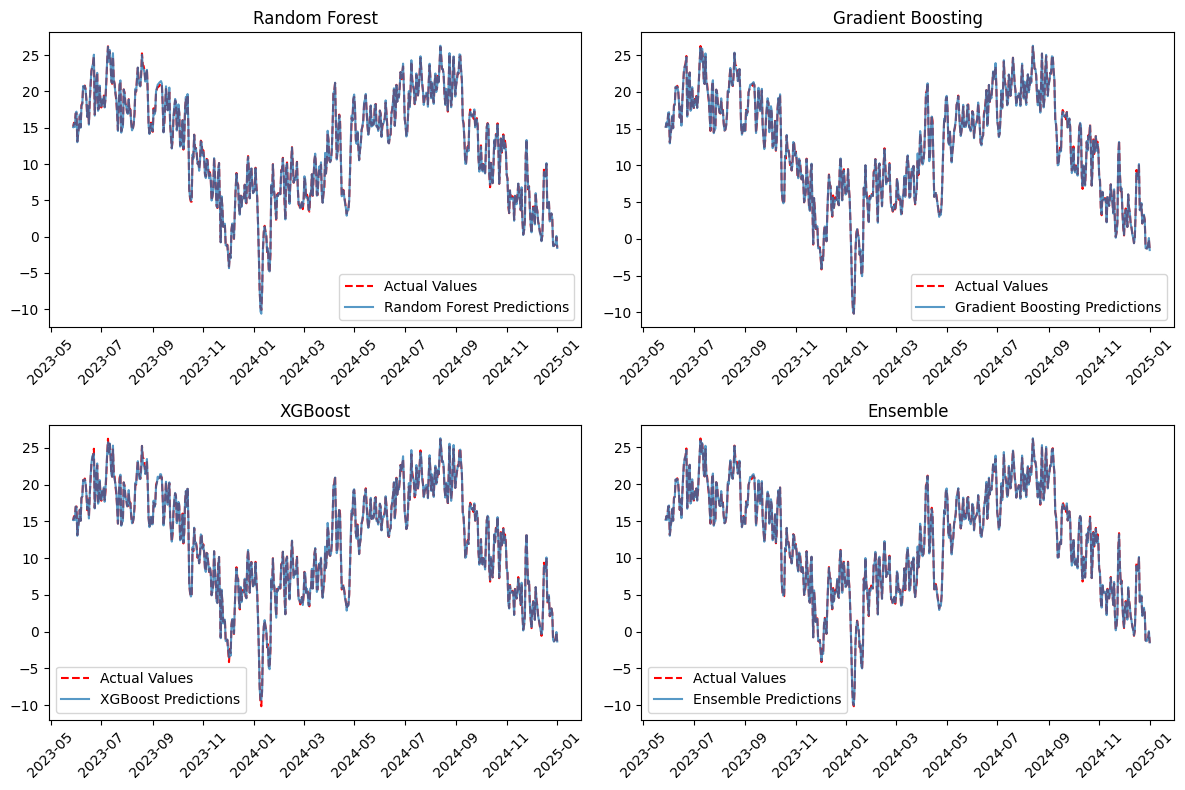

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = pd.read_csv("jena_climate_daily_mean_2017_2024.csv")

# Convert 'Date Time' to datetime format
data['Date Time'] = pd.to_datetime(data['Date Time'], errors='coerce')

# Drop invalid dates
data.dropna(subset=['Date Time'], inplace=True)

# Sort by date
data.sort_values(by='Date Time', inplace=True)

# Extract Month-Day for yearly comparison
data["Month-Day"] = data["Date Time"].dt.strftime("%m-%d")

# Feature selection (Drop "Date Time" and "Month-Day" from X)
X = data.drop(columns=["Date Time", "T (degC)", "Month-Day"])
y = data["T (degC)"]

# Ensure all features are numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize models
rf = RandomForestRegressor(n_estimators=100)
gb = GradientBoostingRegressor(n_estimators=100)
xgb_model = xgb.XGBRegressor(n_estimators=100, objective='reg:squarederror')

# Train models
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Ensemble (Voting Regressor)
ensemble = VotingRegressor([("rf", rf), ("gb", gb), ("xgb", xgb_model)])
ensemble.fit(X_train, y_train)
ensemble_pred = ensemble.predict(X_test)

# Function to Predict Temperature Based on Past Years
def predict_temperature(input_date):
    try:
        target_date = pd.to_datetime(input_date)
        target_month_day = target_date.strftime("%m-%d")

        # Get past years' data for the same month and day
        historical_data = data[data["Month-Day"] == target_month_day]

        if historical_data.empty:
            return f"No historical data available for {input_date}."

        # Extract only the columns used in training (drop "Month-Day", "T (degC)", and "Date Time")
        past_features = historical_data.drop(columns=["Month-Day", "T (degC)", "Date Time"])

        # Ensure features are numeric
        past_features = past_features.apply(pd.to_numeric, errors='coerce')

        # *Match training features exactly*
        past_features = past_features[X_train.columns]

        # Predict temperature using the ensemble model
        predictions = ensemble.predict(past_features)

        # Take the average of all past predictions for the same date
        avg_prediction = np.mean(predictions)

        return f"Predicted temperature on {input_date}: {avg_prediction:.2f}°C"

    except Exception as e:
        return f"Error: {e}"


# Individual Plots for Each Model
dates = data['Date Time'].iloc[-len(y_test):]

models = {
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred,
    "Ensemble": ensemble_pred
}



# Print Performance Metrics
for name, predictions in models.items():
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"{name} - MSE: {mse:.4f} | R²: {r2:.4f}")

# Prediction Example
example_date = input("Enter a date (YYYY-MM-DD) for temperature prediction: ")
print(predict_temperature(example_date))

plt.figure(figsize=(12, 8))
for i, (name, predictions) in enumerate(models.items()):
    plt.subplot(2, 2, i + 1)
    plt.plot(dates, y_test.values, label="Actual Values", color='red', linestyle='dashed')
    plt.plot(dates, predictions, label=f"{name} Predictions", alpha=0.75)
    plt.title(name)
    plt.legend()
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()